In [1]:
# 7-9-2026

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors

,domain_id,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
0,0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,...,0.479085,547.384100,1932.25460,1112.033700,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,...,0.499585,338.661650,1157.09030,705.891970,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,...,0.257699,3360.493400,8181.07230,8625.163000,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,...,0.411259,328.766850,739.65440,901.446350,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,...,0.447848,669.052060,2307.77000,1315.654900,0.185203,1.571907,0.090595,0.007227,0.615066,5
5,5,10.265495,5.699432,17.502420,2.046542,0.978449,3.276847,301.65985,5.860431,307.49870,...,0.491258,615.784000,2284.54270,1215.513500,0.141646,0.628370,0.270441,0.058533,0.560294,4
6,6,3.370416,3.105505,7.804835,3.172674,1.288420,4.654522,280.81445,12.255744,296.83127,...,0.394887,558.122500,2520.26320,715.896240,0.287090,2.909752,0.000000,0.003038,0.626834,4
7,7,11.621094,8.784235,24.302675,3.065614,1.245384,4.709380,295.90033,8.041678,307.00922,...,0.286967,513.446900,1531.67580,1095.658200,0.117847,0.972292,0.076211,0.004830,0.655366,3
8,8,7.512378,2.146205,10.056996,1.712309,1.128670,3.099993,302.63660,2.228121,305.12260,...,0.488031,328.441350,895.73500,747.977050,0.100920,0.937725,0.149864,0.019789,0.553258,5
9,9,3.658946,1.855246,6.112502,3.419243,1.666298,5.511101,287.73157,4.825871,294.05838,...,0.401618,1132.007300,4253.38570,1966.245800,0.543724,5.499713,0.000000,0.002421,0.625943,2


In [3]:
embeddings = pd.read_csv("domain_embeddings_v3.csv")
embeddings

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8
0,0,-0.153192,0.178042,-0.220264,0.007731,-0.307213,0.146843,0.196149,0.265362,-0.027542
1,1,-0.244916,0.217204,-0.265037,0.471137,-0.148067,1.016517,0.633035,0.260105,-0.106379
2,2,0.008171,0.215184,-0.153718,-0.231967,-0.165269,-0.026749,-0.137573,0.131834,1.081505
3,4,-0.112366,-0.011225,0.986331,-0.142931,-0.113171,-0.249637,0.218600,0.164212,-0.046884
4,5,-0.218327,0.145313,-0.318968,-0.022520,-0.284123,0.194040,-0.039714,0.238028,0.039042
5,6,-0.038059,0.006829,0.702497,-0.000403,-0.245892,-0.142117,0.245576,0.038475,-0.040423
6,7,0.040751,0.237239,-0.107122,-0.243791,-0.087197,-0.033741,0.304787,0.190009,-0.080284
7,8,-0.052986,0.198476,-0.100116,0.214855,-0.335965,0.477322,0.394014,0.098428,-0.105724
8,11,-0.228947,0.225434,-0.246083,-0.055765,-0.265403,0.009245,-0.399328,0.218970,0.375242
9,12,-0.666982,0.028853,-0.745364,-0.408598,0.063431,-0.150970,0.092108,0.272048,-0.009432


In [4]:
# corr matrix between embedding dims and raw descriptors
merged_full = embeddings.merge(descriptors, on="domain_id", how="inner")

emb_cols = [c for c in embeddings.columns if c.startswith("e_")]
desc_cols = [c for c in descriptors.columns if c != "domain_id"]

corr_matrix = merged_full[emb_cols + desc_cols].corr(method="spearman").loc[emb_cols, desc_cols]
corr_matrix

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
e_0,-0.269672,-0.116883,-0.192972,0.117800,0.149580,0.118411,-0.537357,0.394347,-0.303896,-0.109244,...,-0.176165,-0.229947,-0.191444,-0.291367,-0.256532,0.111383,-0.464985,-0.205195,0.547441,0.181883
e_1,0.500993,0.292284,0.397097,0.117494,-0.058518,0.116883,0.512911,-0.565775,0.420932,-0.036211,...,-0.289228,0.392208,0.343927,0.413598,0.259282,0.181360,0.365749,0.227196,0.011154,0.111735
e_2,-0.681589,-0.488159,-0.602445,0.335065,0.542246,0.420932,-0.826432,0.609167,-0.733537,-0.196333,...,0.055768,-0.146524,-0.080214,-0.240947,0.089992,0.414515,-0.527217,-0.421849,0.387013,-0.112990
e_3,-0.314286,-0.547135,-0.448739,-0.636975,-0.494576,-0.640947,0.169137,-0.508633,-0.217723,0.871658,...,0.549580,-0.283117,-0.271505,-0.310313,0.105577,0.006875,0.290367,0.436516,0.071658,-0.001726
e_4,-0.000458,0.313675,0.163025,0.403209,0.340565,0.456073,-0.316425,0.543468,-0.061879,-0.665699,...,-0.266310,0.193888,0.221390,0.167609,0.036822,0.172193,-0.331193,-0.526967,-0.234225,-0.038134
e_5,0.134912,-0.134607,-0.008403,-0.445378,-0.417571,-0.468296,0.457907,-0.516578,0.238503,0.477464,...,0.288617,-0.291062,-0.351872,-0.213140,-0.161192,-0.257143,0.270795,0.221085,-0.383957,0.213269
e_6,-0.337510,-0.327731,-0.346371,-0.163331,0.226891,-0.085714,-0.259282,0.190222,-0.260199,0.165164,...,0.082964,-0.911994,-0.909855,-0.876853,-0.715508,-0.490604,-0.561009,-0.285561,-0.067991,0.286086
e_7,0.306035,0.367150,0.328342,0.053629,0.049656,0.027044,0.177082,-0.015126,0.351872,-0.168220,...,-0.167303,-0.045073,-0.068908,0.013904,-0.556608,-0.381818,-0.214526,-0.006570,-0.023377,0.453217
e_8,0.515966,0.444156,0.503438,0.274561,-0.189305,0.170665,0.379679,-0.235752,0.437739,-0.229030,...,-0.251642,0.913827,0.890909,0.889687,0.688006,0.439267,0.567431,0.328342,0.120244,-0.143278


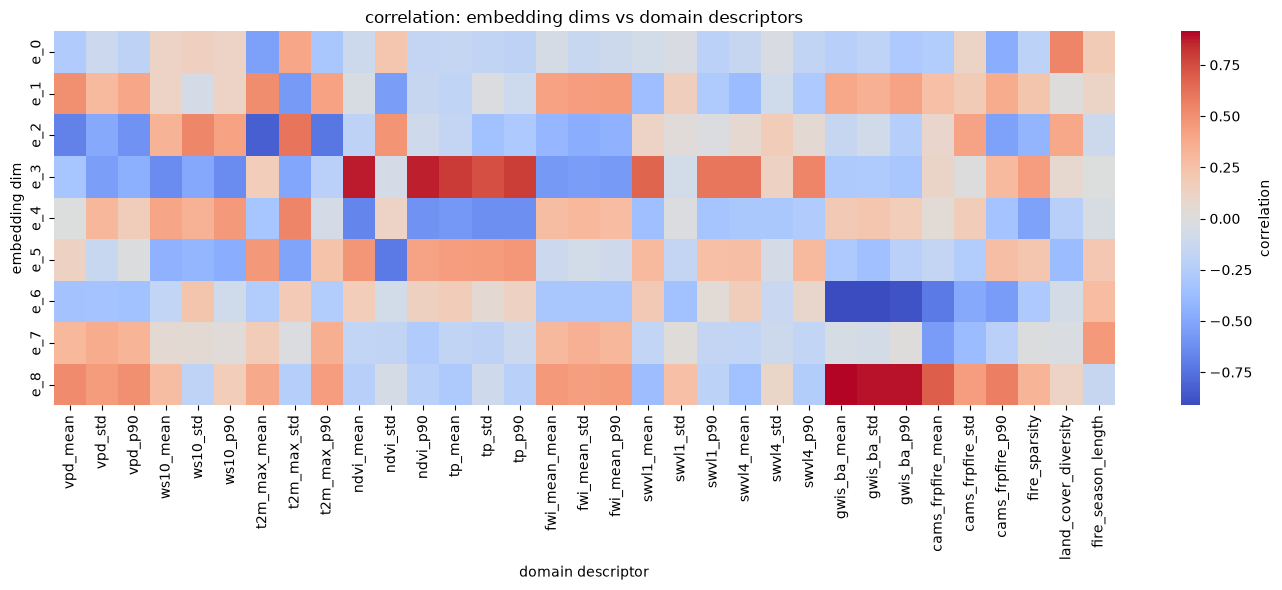

In [5]:
plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, cbar_kws={"label": "correlation"})
plt.xlabel("domain descriptor")
plt.ylabel("embedding dim")
plt.title("correlation: embedding dims vs domain descriptors")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
avg_abs_corr = corr_matrix.abs().mean(axis=1).sort_values(ascending=False)
avg_abs_corr

e_3    0.430348
e_8    0.366825
e_2    0.332704
e_4    0.308263
e_6    0.300545
e_5    0.295832
e_1    0.278335
e_0    0.202036
e_7    0.190649
dtype: float64

In [7]:
atmospheric_cols = ["vpd_mean", "vpd_std", "vpd_p90", "ws10_mean", "ws10_std", "ws10_p90",
                     "t2m_max_mean", "t2m_max_std", "t2m_max_p90", "tp_mean", "tp_std", "tp_p90"]

ground_cols = ["ndvi_mean", "ndvi_std", "ndvi_p90", "swvl1_mean", "swvl1_std", "swvl1_p90",
               "swvl4_mean", "swvl4_std", "swvl4_p90", "land_cover_diversity"]

fire_cols = ["fwi_mean_mean", "fwi_mean_std", "fwi_mean_p90", "gwis_ba_mean", "gwis_ba_std", "gwis_ba_p90",
             "cams_frpfire_mean", "cams_frpfire_std", "cams_frpfire_p90", "fire_sparsity", "fire_season_length"]


In [8]:
branch_cols = {
    "atmospheric": atmospheric_cols,
    "ground": ground_cols,
    "fire": fire_cols
}

# adjust this if your concat order or dims-per-branch differs
dim_to_branch = {
    "e_0": "atmospheric", "e_1": "atmospheric", "e_2": "atmospheric",
    "e_3": "ground", "e_4": "ground", "e_5": "ground",
    "e_6": "fire", "e_7": "fire", "e_8": "fire"
}

In [9]:
rows = []
for dim, own_branch in dim_to_branch.items():
    own_cols = branch_cols[own_branch]
    other_cols = [c for c in corr_matrix.columns if c not in own_cols]

    within = corr_matrix.loc[dim, own_cols].abs().mean()
    outside = corr_matrix.loc[dim, other_cols].abs().mean()

    rows.append({"dim": dim, "branch": own_branch, "within": within, "outside": outside, "gap": within - outside})

separation_df = pd.DataFrame(rows).sort_values("gap", ascending=False)
separation_df

,dim,branch,within,outside,gap
6,e_6,fire,0.541416,0.180110,0.361306
8,e_8,fire,0.563186,0.268644,0.294543
2,e_2,atmospheric,0.502241,0.235826,0.266414
7,e_7,fire,0.245370,0.163289,0.082080
5,e_5,ground,0.332131,0.280049,0.052082
0,e_0,atmospheric,0.227247,0.187630,0.039618
3,e_3,ground,0.449381,0.422073,0.027308
4,e_4,ground,0.318961,0.303612,0.015349
1,e_1,atmospheric,0.273542,0.281073,-0.007531


In [10]:
print("avg within:", separation_df["within"].mean())
print("avg outside:", separation_df["outside"].mean())
# decent gap

avg within: 0.38371951285820427
avg outside: 0.25803401513379914
